In [1]:
import pandas as pd
import io

csv_data = """Shipment_ID,Date,Facility_Type,Urban_Zone,Transit_Mode,Distance_km,Medical_Payload_kg,Traffic_Density_Index,Actual_Fuel_Liters,Actual_CO2e_kg,Late_Delivery_Flag
SHP-1001,2026-08-20,Hospital,High-density,Diesel Truck,45.2,500,0.85,6.5,17.4,0
SHP-1002,2026-08-20,Outpatient Clinic,Low-emission,Electric Van,12.4,150,0.40,0.0,0.0,0
SHP-1003,2026-08-21,Hospital,High-density,Hybrid Van,28.7,320,0.90,2.1,5.6,1
SHP-1004,2026-08-21,Pharmacy,Suburban,Diesel Truck,65.0,800,0.30,8.2,21.9,0
SHP-1005,2026-08-22,Outpatient Clinic,High-density,Electric Van,8.5,100,0.75,0.0,0.0,0
SHP-1006,2026-08-22,Hospital,Suburban,Hybrid Van,35.1,450,0.50,2.6,6.9,0
SHP-1007,2026-08-23,Hospital,High-density,Diesel Truck,50.3,600,0.95,7.8,20.9,1
SHP-1008,2026-08-23,Outpatient Clinic,Low-emission,Electric Van,15.2,200,0.60,0.0,0.0,0
SHP-1009,2026-08-24,Specialty Clinic,High-density,Hybrid Van,18.4,250,0.88,1.4,3.7,1
SHP-1010,2026-08-24,Hospital,Suburban,Diesel Truck,55.8,750,0.45,7.1,19.0,0"""

# Load the dummy data into a DataFrame
df = pd.read_csv(io.StringIO(csv_data))

# Convert Date column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Display the first few rows to verify successful import
df.head()

,Shipment_ID,Date,Facility_Type,Urban_Zone,Transit_Mode,Distance_km,Medical_Payload_kg,Traffic_Density_Index,Actual_Fuel_Liters,Actual_CO2e_kg,Late_Delivery_Flag
0,SHP-1001,2026-08-20,Hospital,High-density,Diesel Truck,45.2,500,0.85,6.5,17.4,0
1,SHP-1002,2026-08-20,Outpatient Clinic,Low-emission,Electric Van,12.4,150,0.40,0.0,0.0,0
2,SHP-1003,2026-08-21,Hospital,High-density,Hybrid Van,28.7,320,0.90,2.1,5.6,1
3,SHP-1004,2026-08-21,Pharmacy,Suburban,Diesel Truck,65.0,800,0.30,8.2,21.9,0
4,SHP-1005,2026-08-22,Outpatient Clinic,High-density,Electric Van,8.5,100,0.75,0.0,0.0,0


In [9]:
print("--- Dataset Information ---")
df.info()
df.shape

print("\n--- Descriptive Statistics ---")
print(df.describe())

print("\n--- First 5 Rows of the Dataset ---")
print(df.head())

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Shipment_ID                      10 non-null     object        
 1   Date                             10 non-null     datetime64[ns]
 2   Facility_Type                    10 non-null     object        
 3   Urban_Zone                       10 non-null     object        
 4   Transit_Mode                     10 non-null     object        
 5   Distance_km                      10 non-null     float64       
 6   Medical_Payload_kg               10 non-null     int64         
 7   Traffic_Density_Index            10 non-null     float64       
 8   Actual_Fuel_Liters               10 non-null     float64       
 9   Actual_CO2e_kg                   10 non-null     float64       
 10  Late_Delivery_Flag               10 n

In [10]:
rows, cols = df.shape
print(f"The dataset has {rows} rows and {cols} columns.")

The dataset has 10 rows and 19 columns.


In [4]:
# Identify features Distance_km, Medical_Payload_kg, and Traffic_Density_Index
# Scikit-Learn to build a Multiple Linear Regression model.
# Add the Predicted_CO2e_kg column directly to the active DataFrame

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# 1. Select Features (X) and Target (y)
X = df[['Distance_km', 'Medical_Payload_kg', 'Traffic_Density_Index', 'Transit_Mode']]
y = df['Actual_CO2e_kg']

# 2. Encode categorical data ('Transit_Mode') into numerical format
X_encoded = pd.get_dummies(X, columns=['Transit_Mode'], drop_first=False)

# 3. Split the data into Training and Testing sets
# (Using a 80/20 split. With only 10 dummy rows, this serves to validate the pipeline)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 4. Initialize and train the baseline regression model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Evaluate model performance on the test set
y_pred_test = model.predict(X_test)
print("--- Model Evaluation ---")
print(f"R-squared (Accuracy): {r2_score(y_test, y_pred_test):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_test):.4f}\n")

# 6. Generate the proactive 'Predicted_CO2e_kg' metric for the entire DataFrame
df['Predicted_CO2e_kg'] = model.predict(X_encoded).round(2)

# Display the results side-by-side to review the variance
df[['Shipment_ID', 'Transit_Mode', 'Actual_CO2e_kg', 'Predicted_CO2e_kg']].head(10)

--- Model Evaluation ---
R-squared (Accuracy): 0.3799
Mean Squared Error: 2.1223



,Shipment_ID,Transit_Mode,Actual_CO2e_kg,Predicted_CO2e_kg
0,SHP-1001,Diesel Truck,17.4,17.68
1,SHP-1002,Electric Van,0.0,-1.57
2,SHP-1003,Hybrid Van,5.6,6.27
3,SHP-1004,Diesel Truck,21.9,21.77
4,SHP-1005,Electric Van,0.0,-0.81
5,SHP-1006,Hybrid Van,6.9,6.23
6,SHP-1007,Diesel Truck,20.9,20.34
7,SHP-1008,Electric Van,0.0,0.81
8,SHP-1009,Hybrid Van,3.7,2.37
9,SHP-1010,Diesel Truck,19.0,19.40


In [7]:
import numpy as np

# 1. Total Predicted Emissions (CO2e)
total_predicted_emissions = df['Predicted_CO2e_kg'].sum()
print(f"Total Predicted Emissions (CO2e): {total_predicted_emissions:.2f} kg")

# 2. Emissions Intensity (CO2e per Kg of Payload)
# Handle division by zero for Medical_Payload_kg
df['Emissions_Intensity_CO2e_per_kg'] = df['Predicted_CO2e_kg'] / df['Medical_Payload_kg']
df['Emissions_Intensity_CO2e_per_kg'] = df['Emissions_Intensity_CO2e_per_kg'].replace([np.inf, -np.inf], np.nan)
df['Emissions_Intensity_CO2e_per_kg'] = df['Emissions_Intensity_CO2e_per_kg'].fillna(0) # Assuming 0 intensity if no payload

mean_emissions_intensity = df['Emissions_Intensity_CO2e_per_kg'].mean()
print(f"Mean Emissions Intensity (CO2e per Kg of Payload): {mean_emissions_intensity:.4f} kg CO2e/kg Payload")

# 3. Carbon Savings (Optimized vs. Baseline)
# Define a baseline: average CO2e per km for 'Diesel Truck' from the actual data
diesel_truck_data = df[df['Transit_Mode'] == 'Diesel Truck'].copy()
diesel_truck_data = diesel_truck_data[diesel_truck_data['Distance_km'] > 0]

if not diesel_truck_data.empty:
    mean_diesel_co2e_per_km = (diesel_truck_data['Actual_CO2e_kg'] / diesel_truck_data['Distance_km']).mean()
else:
    # Fallback if no diesel truck data or all have 0 distance, use a reasonable default
    mean_diesel_co2e_per_km = 0.4  # kg CO2e/km (dummy value)

# Calculate baseline CO2e for all shipments as if they were Diesel Trucks
df['Baseline_Diesel_CO2e_kg'] = df['Distance_km'] * mean_diesel_co2e_per_km
# Carbon Savings: Baseline - Predicted
df['Carbon_Savings_kg'] = df['Baseline_Diesel_CO2e_kg'] - df['Predicted_CO2e_kg']

total_carbon_savings = df['Carbon_Savings_kg'].sum()
print(f"Total Carbon Savings (Baseline Diesel vs. Predicted): {total_carbon_savings:.2f} kg CO2e")

# 4. Late Delivery vs. High Emission Correlation
# Group by Late_Delivery_Flag and calculate mean Predicted_CO2e_kg
emissions_by_delivery_status = df.groupby('Late_Delivery_Flag')['Predicted_CO2e_kg'].mean()
print("\nMean Predicted CO2e by Delivery Status:")
print(emissions_by_delivery_status)

# Calculate correlation coefficient between Late_Delivery_Flag and Predicted_CO2e_kg
correlation_late_delivery_emissions = df['Late_Delivery_Flag'].corr(df['Predicted_CO2e_kg'])
print(f"Correlation between Late Delivery and Predicted CO2e: {correlation_late_delivery_emissions:.4f}")

# 5. Estimated Fuel Cost Variance
# Assume fuel costs per liter (dummy values)
cost_per_liter_diesel = 1.50  # USD/Liter
cost_per_liter_hybrid = 1.50  # USD/Liter (assuming similar to diesel fuel)

# Calculate Actual Fuel Cost based on Transit Mode and Actual_Fuel_Liters
def calculate_actual_fuel_cost(row):
    if row['Transit_Mode'] == 'Diesel Truck':
        return row['Actual_Fuel_Liters'] * cost_per_liter_diesel
    elif row['Transit_Mode'] == 'Hybrid Van':
        return row['Actual_Fuel_Liters'] * cost_per_liter_hybrid
    else:  # Electric Van (Actual_Fuel_Liters is 0.0)
        return 0.0

df['Actual_Fuel_Cost'] = df.apply(calculate_actual_fuel_cost, axis=1)

# Calculate Baseline Fuel Liters based on Baseline Diesel CO2e
# Derive a relationship between Actual_Fuel_Liters and Actual_CO2e_kg for Diesel Trucks
diesel_fuel_liters_per_co2e_data = diesel_truck_data[diesel_truck_data['Actual_CO2e_kg'] > 0]

if not diesel_fuel_liters_per_co2e_data.empty:
    mean_diesel_fuel_liters_per_co2e = (diesel_fuel_liters_per_co2e_data['Actual_Fuel_Liters'] / diesel_fuel_liters_per_co2e_data['Actual_CO2e_kg']).mean()
else:
    # Fallback if no diesel truck data or all have 0 CO2e, use a reasonable default
    mean_diesel_fuel_liters_per_co2e = 0.3  # Liters/kg CO2e (dummy value)

df['Baseline_Diesel_Fuel_Liters'] = df['Baseline_Diesel_CO2e_kg'] * mean_diesel_fuel_liters_per_co2e
df['Baseline_Fuel_Cost'] = df['Baseline_Diesel_Fuel_Liters'] * cost_per_liter_diesel

# Estimated Fuel Cost Variance: Actual Fuel Cost - Baseline Fuel Cost
df['Estimated_Fuel_Cost_Variance'] = df['Actual_Fuel_Cost'] - df['Baseline_Fuel_Cost']

total_estimated_fuel_cost_variance = df['Estimated_Fuel_Cost_Variance'].sum()
print(f"\nTotal Estimated Fuel Cost Variance (Actual - Baseline Diesel): {total_estimated_fuel_cost_variance:.2f} USD")

print("\nDataFrame with new calculated metrics (first 10 rows):")
print(df[['Shipment_ID', 'Transit_Mode', 'Distance_km', 'Medical_Payload_kg',
          'Actual_CO2e_kg', 'Predicted_CO2e_kg', 'Emissions_Intensity_CO2e_per_kg',
          'Carbon_Savings_kg', 'Late_Delivery_Flag', 'Actual_Fuel_Cost',
          'Baseline_Fuel_Cost', 'Estimated_Fuel_Cost_Variance']].head(10))

Total Predicted Emissions (CO2e): 92.49 kg
Mean Emissions Intensity (CO2e per Kg of Payload): 0.0151 kg CO2e/kg Payload
Total Carbon Savings (Baseline Diesel vs. Predicted): 31.14 kg CO2e

Mean Predicted CO2e by Delivery Status:
Late_Delivery_Flag
0    9.072857
1    9.660000
Name: Predicted_CO2e_kg, dtype: float64
Correlation between Late Delivery and Predicted CO2e: 0.0299

Total Estimated Fuel Cost Variance (Actual - Baseline Diesel): -15.75 USD

DataFrame with new calculated metrics (first 10 rows):
  Shipment_ID  Transit_Mode  Distance_km  Medical_Payload_kg  Actual_CO2e_kg  \
0    SHP-1001  Diesel Truck         45.2                 500            17.4   
1    SHP-1002  Electric Van         12.4                 150             0.0   
2    SHP-1003    Hybrid Van         28.7                 320             5.6   
3    SHP-1004  Diesel Truck         65.0                 800            21.9   
4    SHP-1005  Electric Van          8.5                 100             0.0   
5    SHP-100

In [11]:
total_actual_emissions = df['Actual_CO2e_kg'].sum()
print(f"Total Actual Emissions (CO2e): {total_actual_emissions:.2f} kg")

Total Actual Emissions (CO2e): 95.40 kg


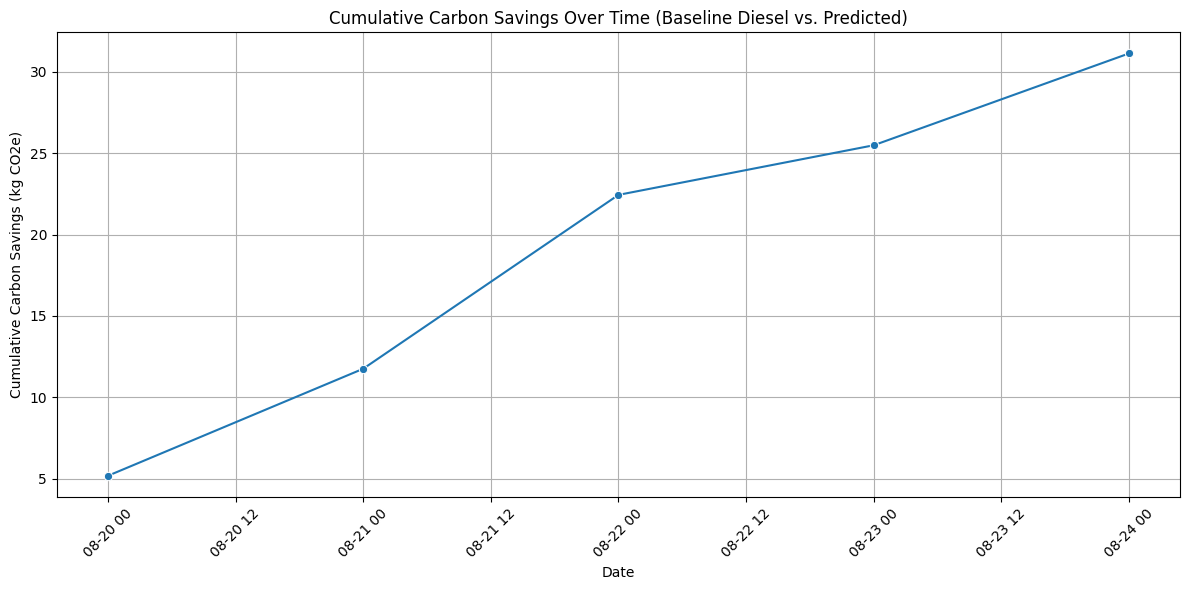

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Date' is datetime and sort for cumulative calculation
df['Date'] = pd.to_datetime(df['Date'])
df_sorted = df.sort_values(by='Date').copy()

# Calculate Cumulative Carbon Savings
df_cumulative_carbon = df_sorted.groupby('Date')['Carbon_Savings_kg'].sum().reset_index()
df_cumulative_carbon['Cumulative_Carbon_Savings_kg'] = df_cumulative_carbon['Carbon_Savings_kg'].cumsum()

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_cumulative_carbon, x='Date', y='Cumulative_Carbon_Savings_kg', marker='o')
plt.title('Cumulative Carbon Savings Over Time (Baseline Diesel vs. Predicted)')
plt.xlabel('Date')
plt.ylabel('Cumulative Carbon Savings (kg CO2e)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_999/170604067.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_emissions_by_mode.index, y=avg_emissions_by_mode.values, palette='viridis')


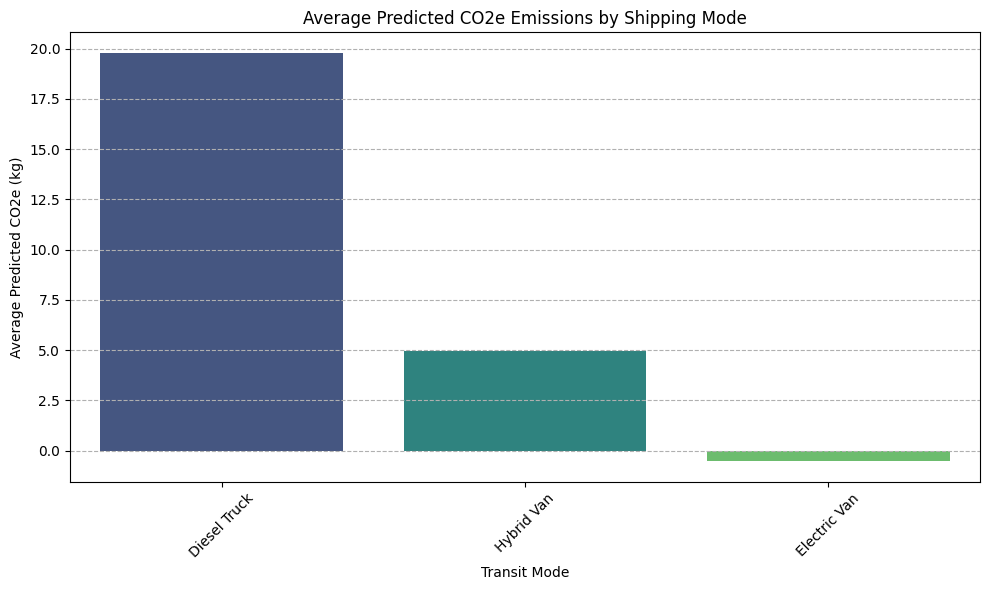

In [13]:
# Calculate Average Emissions by Shipping Mode
avg_emissions_by_mode = df.groupby('Transit_Mode')['Predicted_CO2e_kg'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_emissions_by_mode.index, y=avg_emissions_by_mode.values, palette='viridis')
plt.title('Average Predicted CO2e Emissions by Shipping Mode')
plt.xlabel('Transit Mode')
plt.ylabel('Average Predicted CO2e (kg)')
plt.grid(axis='y', linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

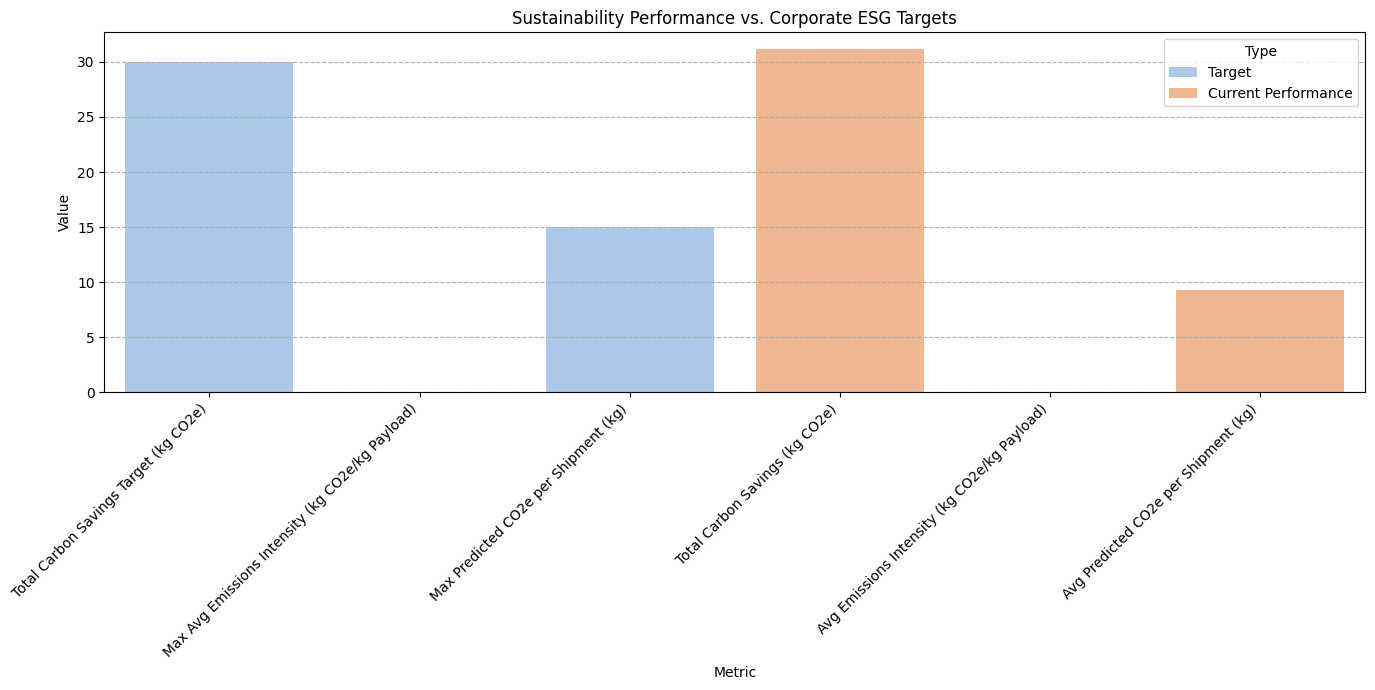


--- Sustainability Performance vs. ESG Targets Summary ---
  Total Carbon Savings Target (kg CO2e): 30.00 kg CO2e | Current: 31.14 kg CO2e | Status: Met
  Max Avg Emissions Intensity (kg CO2e/kg Payload): 0.0200 | Current: 0.0151 | Status: Met
  Max Predicted CO2e per Shipment (kg): 15.00 kg | Current: 9.25 kg | Status: Met


In [14]:
# Overall Sustainability Performance against Corporate ESG Targets

# Define hypothetical ESG targets (dummy values for illustration)
# These targets should be defined based on actual corporate goals.

esg_targets = {
    'Total Carbon Savings Target (kg CO2e)': 30, # Example: Target to save at least 30 kg CO2e
    'Max Avg Emissions Intensity (kg CO2e/kg Payload)': 0.02, # Example: Max average intensity of 0.02
    'Max Predicted CO2e per Shipment (kg)': 15 # Example: Max average predicted CO2e per shipment of 15 kg
}

# Calculate current performance metrics
current_performance = {
    'Total Carbon Savings (kg CO2e)': df['Carbon_Savings_kg'].sum(),
    'Avg Emissions Intensity (kg CO2e/kg Payload)': df['Emissions_Intensity_CO2e_per_kg'].mean(),
    'Avg Predicted CO2e per Shipment (kg)': df['Predicted_CO2e_kg'].mean()
}

# Combine into a DataFrame for plotting
esg_df = pd.DataFrame({
    'Metric': list(esg_targets.keys()) + list(current_performance.keys()),
    'Value': list(esg_targets.values()) + list(current_performance.values()),
    'Type': ['Target'] * len(esg_targets) + ['Current Performance'] * len(current_performance)
})

plt.figure(figsize=(14, 7))
sns.barplot(x='Metric', y='Value', hue='Type', data=esg_df, palette='pastel')
plt.title('Sustainability Performance vs. Corporate ESG Targets')
plt.ylabel('Value')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# Optional: Print a summary to easily see performance against targets
print("\n--- Sustainability Performance vs. ESG Targets Summary ---")
for target_name, target_value in esg_targets.items():
    if 'Savings' in target_name:
        current_value = current_performance['Total Carbon Savings (kg CO2e)']
        status = 'Met' if current_value >= target_value else 'Not Met'
        print(f"  {target_name}: {target_value:.2f} kg CO2e | Current: {current_value:.2f} kg CO2e | Status: {status}")
    elif 'Max Avg Emissions Intensity' in target_name:
        current_value = current_performance['Avg Emissions Intensity (kg CO2e/kg Payload)']
        status = 'Met' if current_value <= target_value else 'Not Met'
        print(f"  {target_name}: {target_value:.4f} | Current: {current_value:.4f} | Status: {status}")
    elif 'Max Predicted CO2e per Shipment' in target_name:
        current_value = current_performance['Avg Predicted CO2e per Shipment (kg)']
        status = 'Met' if current_value <= target_value else 'Not Met'
        print(f"  {target_name}: {target_value:.2f} kg | Current: {current_value:.2f} kg | Status: {status}")